# Rayleigh numbers

## Load the simulations

In [4]:
import numpy as np
from lucifex.fem import refine_grid_function
from lucifex.viz import plot_colormap, plot_line
from lucifex.utils.array_utils import as_index
from lucifex.io import find_dir_paths
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE

sim_dir_paths = find_dir_paths(
    './data', 
    include='n_stop=99999_*',
    contains='CHECKPOINT.h5',
)
print('Before filtering')
for i in sim_dir_paths: print(i)

parameters = {k: v for k, v in SYSTEM_A_REFERENCE.items() if k != 'Ra'}

_simulations = GridSimulationFromNPZ.from_dir_paths(
    sim_dir_paths, 
    ('c', 's'),
    ('f', 'mD', 'mC'),
    parameters,
    lazy=False,
)
simulations: dict[float, GridSimulationFromNPZ] = {
    sim['Ra']: sim for sim in _simulations
}

print('After filtering')
for i in simulations.values(): print(i.dir_path)

Before filtering
./data/n_stop=99999__Ra=1000.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__be3a9e8633d4e7cb/
./data/n_stop=99999__Ra=1000.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__dbd2dc756c173b82/
./data/n_stop=99999__Ra=2000.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__a77653727d77da29/
./data/n_stop=99999__Ra=2000.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__4684292dc9e109cc/
After filtering
./data/n_stop=99999__Ra=1000.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__dbd2dc756c173b82/
./data/n_stop=99999__Ra=2000.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__4684292dc9e109cc/


In [ ]:
name = 'c'
for Ra, sim in simulations.items():
    print(f'Ra = {Ra}')
    time_series = sim[name].time_series
    print(f"n_time = {len(time_series)} t_min = {np.min(time_series)}  t_max = {np.max(time_series)}")

Ra = 1000.0
n_time = 2593 t_min = 0.0  t_max = 119.99419142497204
Ra = 2000.0
n_time = 1484 t_min = 0.0  t_max = 119.99110774612869


## Physical diagnostics

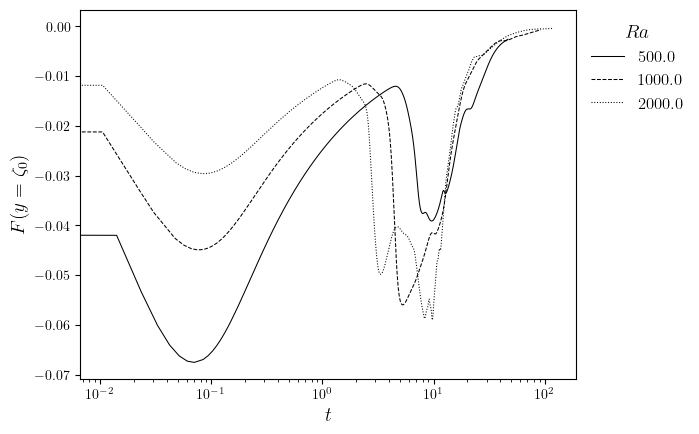

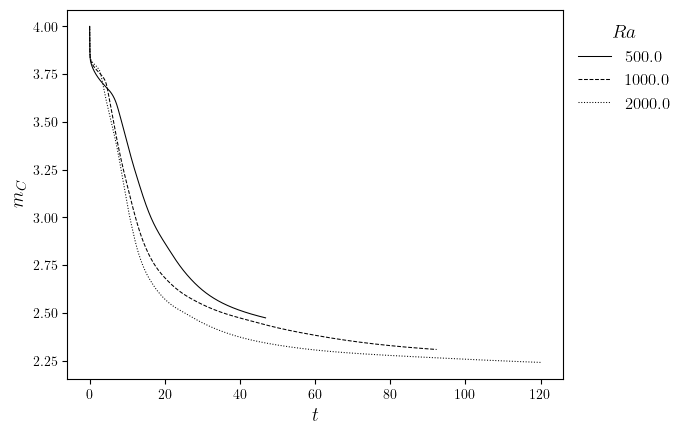

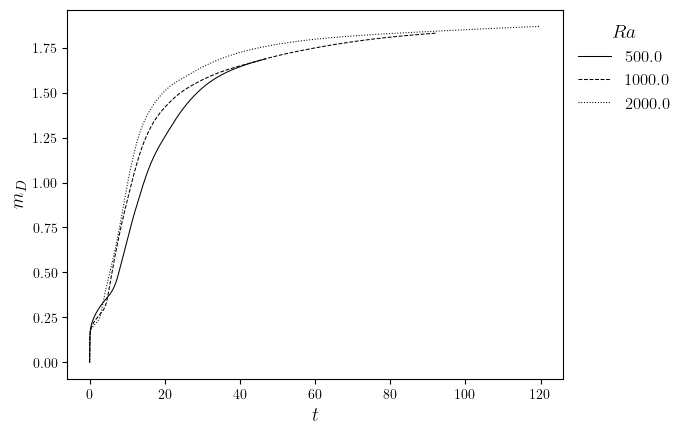

In [2]:
f_lines, mC_lines, mD_lines = [], [], []
legend_labels = []
for Ra, sim in simulations.items():
    f, mC, mD = sim['f', 'mC', 'mD']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    f_lines.append((fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]))
    mC_lines.append((mC.time_series, mC.value_series))
    mD_lines.append((mD.time_series, mD.value_series))
    legend_labels.append(Ra)

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=legend_labels,
    legend_title='$Ra$',
)

fig, ax = plot_line(f_lines, y_label='$F(y=\zeta_0)$', **line_kws)
ax.set_xscale('log')

fig, ax = plot_line(mC_lines, y_label='$m_C$', **line_kws)

fig, ax = plot_line(mD_lines, y_label='$m_D$', **line_kws)

## Visualization

### Concentration

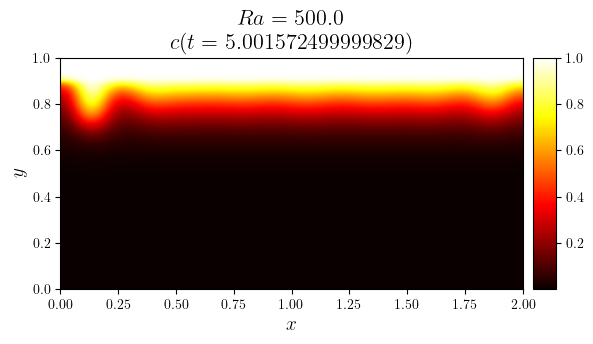

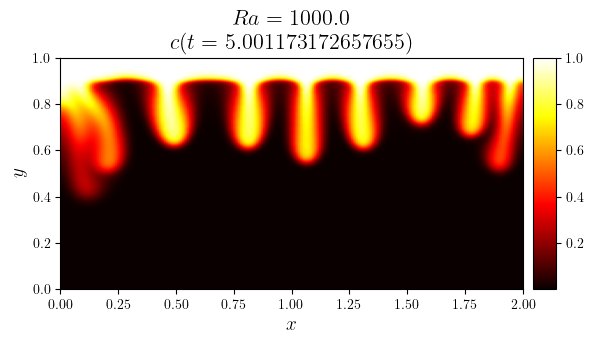

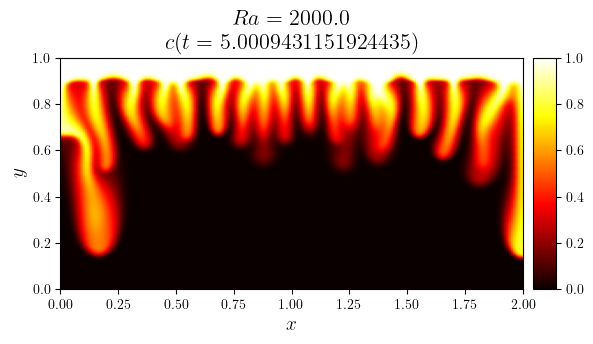

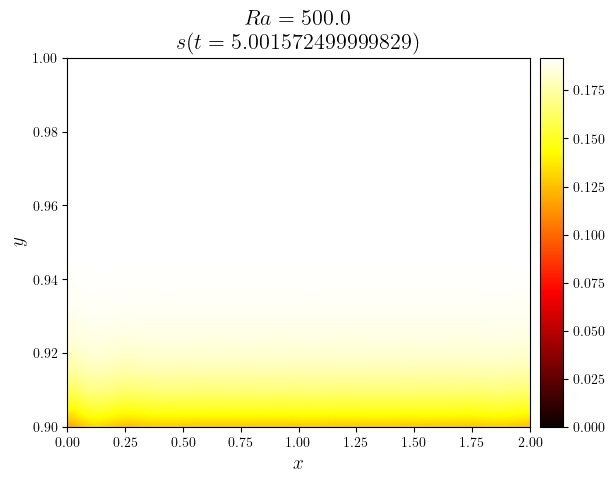

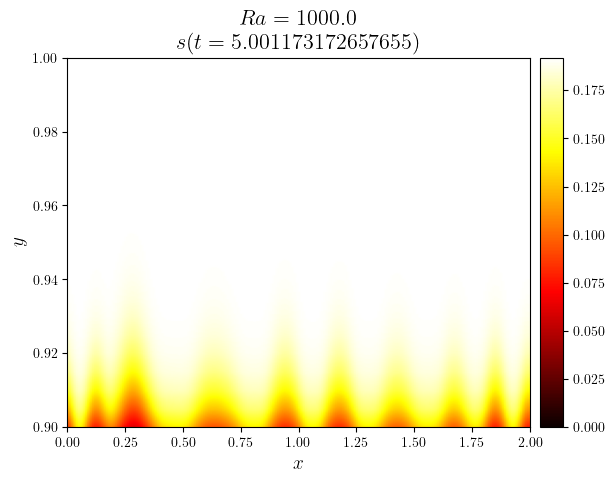

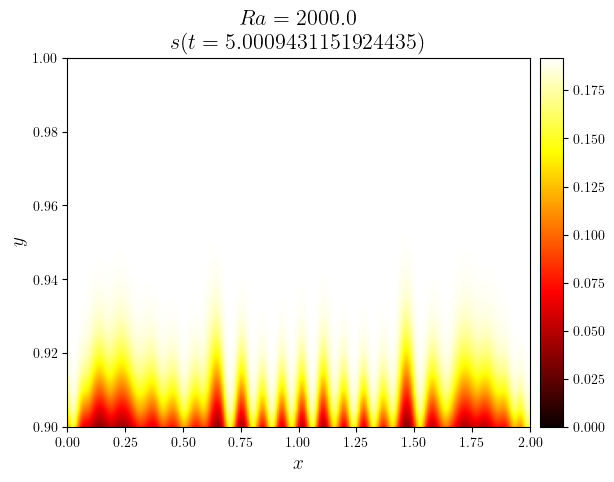

In [ ]:
c_t_target = 5.0
for Ra, sim in simulations.items():
    c = sim['c']
    time_index = as_index(c.time_series, c_t_target)
    fig, ax = plot_colormap(
        c.series[time_index], 
        title=f'$Ra={Ra}$\n$c(t={c.time_series[time_index]})$',
    )

### Saturation

In [ ]:
Ly = 1.0
s_t_target = 5.0
for Ra, sim in simulations.items():
    s = sim['s']
    zeta0 = sim['zeta0']
    time_index = as_index(s.time_series, s_t_target)
    fig, ax = plot_colormap(
        refine_grid_function(s.series[time_index], (1, 20)), 
        title=f'$Ra={Ra}$\n$s(t={s.time_series[time_index]})$',
        y_lims=(zeta0 * Ly, Ly),
        aspect='auto',
    )

## Numerical diagnostics

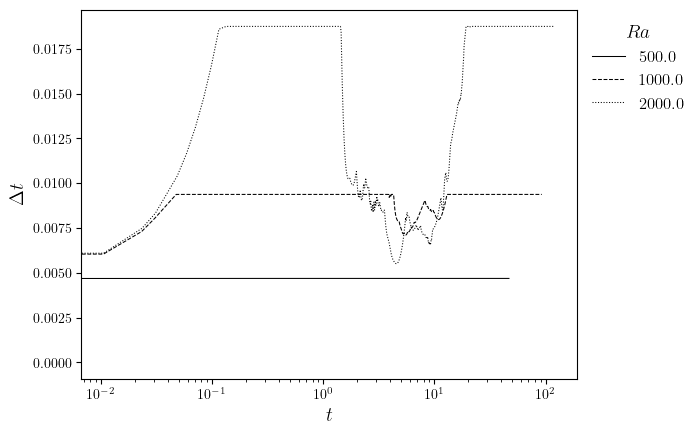

In [ ]:
[sim.include_constant_series('dt', lazy=False) for sim in simulations.values()]

dt_lines = []
legend_labels = []
for Ra, sim in simulations.items():
    dt = sim['dt']
    dt_lines.append((dt.time_series, dt.value_series))
    legend_labels.append(Ra)

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=legend_labels,
    legend_title='$Ra$',
)

fig, ax = plot_line(dt_lines, y_label='$\Delta t$', **line_kws)
ax.set_xscale('log')